<a href="https://colab.research.google.com/github/22f1001966/22f1001966_my_new_repository/blob/main/Copy_of_Day1_EDA_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Load the Dataset

Load the train and test data



In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.dummy import DummyRegressor
model = DummyRegressor()
#model.fit(X,y)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
train = pd.read_csv('/content/drive/MyDrive/train_data.csv')
test = pd.read_csv('/content/drive/MyDrive/test_data.csv')

Mounted at /content/drive


## Questions

1. How many observations are available in the dataset?
2. How many features are available?




In [ ]:
print(train.shape)
print(test.shape)

(116023, 52)
(29006, 51)


In [ ]:
type(train)

pandas.core.frame.DataFrame

In [ ]:
train.columns

Index(['trafficSource.isTrueDirect', 'purchaseValue', 'browser',
       'device.screenResolution', 'trafficSource.adContent',
       'trafficSource.keyword', 'screenSize', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'device.mobileDeviceBranding',
       'device.mobileInputSelector', 'userId', 'trafficSource.campaign',
       'device.mobileDeviceMarketingName', 'geoNetwork.networkDomain',
       'gclIdPresent', 'device.operatingSystemVersion', 'sessionNumber',
       'device.flashVersion', 'geoNetwork.region', 'trafficSource',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId', 'os',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor',
       'locationCountry', 'device.browserSize',
       'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
       'geoNetwork.city', 'trafficSource.adwordsClickInfo.page',
       'geoNetwork.metro', 'pageViews', 'locationZone',
      

In [ ]:
train['device.isMobile'].head()

,device.isMobile
0,False
1,False
2,False
3,False
4,False


In [ ]:
train.select_dtypes(include='bool')

,device.isMobile
0,False
1,False
2,False
3,False
4,False
...,...
116018,False
116019,False
116020,False
116021,False


In [ ]:
train.head()

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1500100799,Americas,False,1.0
1,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1495262065,Americas,False,1.0
2,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,6,not available in demo dataset,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,not available in demo dataset,NaN,NaN,medium,Region_4,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,66,not available in demo dataset,1475804633,Americas,False,1.0


In [ ]:
train.columns.difference(test.columns)

Index(['purchaseValue'], dtype='object')

In [ ]:
test.head()

,userChannel,date,browser,device.browserSize,device.browserVersion,deviceType,device.flashVersion,device.isMobile,device.language,device.mobileDeviceBranding,...,trafficSource,sessionId,sessionNumber,sessionStart,userId,locationZone,geoCluster,browserMajor,screenSize,gclIdPresent
0,Social,20170508,Chrome,not available in demo dataset,not available in demo dataset,desktop,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,...,groups.google.com,1494262567,2,1494262567,59555,8,Region_2,not available in demo dataset,medium,0
1,Organic Search,20170405,Chrome,not available in demo dataset,not available in demo dataset,desktop,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,...,google,1491433811,1,1491433811,6394,8,Region_1,not available in demo dataset,medium,0
2,Organic Search,20170308,Safari,not available in demo dataset,not available in demo dataset,desktop,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,...,google,1489001815,1,1489001815,38969,8,Region_5,not available in demo dataset,medium,0
3,Referral,20171113,Chrome,not available in demo dataset,not available in demo dataset,desktop,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,...,docs.google.com,1510593024,30,1510593024,120027,8,Region_2,not available in demo dataset,medium,0
4,Organic Search,20161212,Chrome,not available in demo dataset,not available in demo dataset,desktop,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,...,(direct),1481559809,1,1481559809,69453,8,Region_3,not available in demo dataset,medium,0


Target Variable ( the column present in train but not in test)

purchaseValue: The amount (in currency units) spent by the customer during the session. This is the target variable to be predicted.

In [ ]:
y_train=train["purchaseValue"].head()
y_train

,purchaseValue
0,0.0
1,0.0
2,0.0
3,0.0
4,88950000.0


# Step 2: Understanding the Structure of the Dataset

The first step in EDA is understanding how the dataset is organized.

We need to know

- Data types
- Missing values
- Number of non-null observations



## Questions

1. Which columns are numerical?
2. Which columns are categorical?
3. Are there Boolean variables?
4. Are there datetime columns?
5. Are any columns stored using an incorrect datatype?
6. Can you identify any columns that look like identifiers?

In [ ]:
train.dtypes.value_counts()

,count
object,37
int64,9
float64,5
bool,1


#In the train_data.csv The categorical datatypes are 37 and numerical datatypes are 14 and booleans are 1

In [ ]:
train.select_dtypes(include='number')

,purchaseValue,userId,gclIdPresent,sessionNumber,totals.visits,sessionId,trafficSource.adwordsClickInfo.page,pageViews,locationZone,totals.bounces,date,totalHits,sessionStart,new_visits
0,0.0,61421,0,1,1,1500100799,NaN,1.0,8,1.0,20170714,1,1500100799,1.0
1,0.0,72287,0,1,1,1495262065,NaN,1.0,8,1.0,20170519,1,1495262065,1.0
2,0.0,25180,0,2,1,1508510328,NaN,6.0,8,NaN,20171020,6,1508510328,NaN
3,0.0,41295,0,1,1,1483431838,NaN,1.0,8,1.0,20170103,1,1483431838,1.0
4,88950000.0,113697,0,1,1,1475804633,NaN,54.0,8,NaN,20161006,66,1475804633,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116018,35180000.0,109014,0,1,1,1500318402,NaN,26.0,8,NaN,20170717,28,1500318402,1.0
116019,0.0,66111,0,1,1,1478624150,NaN,1.0,8,1.0,20161108,1,1478624150,1.0
116020,0.0,97614,0,2,1,1470384216,NaN,1.0,8,1.0,20160805,1,1470384216,NaN
116021,0.0,71050,0,1,1,1506953297,NaN,2.0,8,NaN,20171002,2,1506953297,1.0


In [ ]:
train.select_dtypes(exclude='number')

,trafficSource.isTrueDirect,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,...,geoNetwork.metro,device.mobileDeviceModel,trafficSource.referralPath,device.language,deviceType,userChannel,device.browserVersion,device.screenColors,geoNetwork.continent,device.isMobile
0,NaN,Edge,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,...,Seattle-Tacoma WA,not available in demo dataset,/intl/hr/yt/about/,not available in demo dataset,desktop,Social,not available in demo dataset,not available in demo dataset,Americas,False
1,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,...,San Francisco-Oakland-San Jose CA,not available in demo dataset,NaN,not available in demo dataset,desktop,Direct,not available in demo dataset,not available in demo dataset,Americas,False
2,True,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,...,(not set),not available in demo dataset,NaN,not available in demo dataset,desktop,Organic Search,not available in demo dataset,not available in demo dataset,Europe,False
3,NaN,Internet Explorer,not available in demo dataset,NaN,NaN,medium,Region_4,NaN,not available in demo dataset,not available in demo dataset,...,not available in demo dataset,not available in demo dataset,/yt/about/ja/,not available in demo dataset,desktop,Social,not available in demo dataset,not available in demo dataset,Asia,False
4,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,...,not available in demo dataset,not available in demo dataset,NaN,not available in demo dataset,desktop,Direct,not available in demo dataset,not available in demo dataset,Americas,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116018,NaN,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,...,New York NY,not available in demo dataset,/,not available in demo dataset,desktop,Referral,not available in demo dataset,not available in demo dataset,Americas,False
116019,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_5,NaN,not available in demo dataset,not available in demo dataset,...,San Francisco-Oakland-San Jose CA,not available in demo dataset,NaN,not available in demo dataset,desktop,Direct,not available in demo dataset,not available in demo dataset,Americas,False
116020,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_1,NaN,not available in demo dataset,not available in demo dataset,...,(not set),not available in demo dataset,/google-analytics-launches-public-demo-account...,not available in demo dataset,desktop,Referral,not available in demo dataset,not available in demo dataset,Asia,False
116021,NaN,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_5,NaN,not available in demo dataset,not available in demo dataset,...,Nashville TN,not available in demo dataset,NaN,not available in demo dataset,desktop,Organic Search,not available in demo dataset,not available in demo dataset,Americas,False


In [ ]:
train.select_dtypes(exclude='object')

,purchaseValue,userId,gclIdPresent,sessionNumber,totals.visits,sessionId,trafficSource.adwordsClickInfo.page,pageViews,locationZone,totals.bounces,date,totalHits,sessionStart,device.isMobile,new_visits
0,0.0,61421,0,1,1,1500100799,NaN,1.0,8,1.0,20170714,1,1500100799,False,1.0
1,0.0,72287,0,1,1,1495262065,NaN,1.0,8,1.0,20170519,1,1495262065,False,1.0
2,0.0,25180,0,2,1,1508510328,NaN,6.0,8,NaN,20171020,6,1508510328,False,NaN
3,0.0,41295,0,1,1,1483431838,NaN,1.0,8,1.0,20170103,1,1483431838,False,1.0
4,88950000.0,113697,0,1,1,1475804633,NaN,54.0,8,NaN,20161006,66,1475804633,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116018,35180000.0,109014,0,1,1,1500318402,NaN,26.0,8,NaN,20170717,28,1500318402,False,1.0
116019,0.0,66111,0,1,1,1478624150,NaN,1.0,8,1.0,20161108,1,1478624150,False,1.0
116020,0.0,97614,0,2,1,1470384216,NaN,1.0,8,1.0,20160805,1,1470384216,False,NaN
116021,0.0,71050,0,1,1,1506953297,NaN,2.0,8,NaN,20171002,2,1506953297,False,1.0


In [ ]:
missing = train.isnull().sum().sort_values(ascending=False)
missing
#missing1 = test.isnull().sum().sort_values(ascending=False)
#missing1

,0
trafficSource.adContent,113060
trafficSource.adwordsClickInfo.slot,111742
trafficSource.adwordsClickInfo.adNetworkType,111742
trafficSource.adwordsClickInfo.isVideoAd,111742
trafficSource.adwordsClickInfo.page,111742
trafficSource.referralPath,73309
trafficSource.isTrueDirect,73133
trafficSource.keyword,71861
totals.bounces,68875
new_visits,35505


In [ ]:
missing_percent=(train.isnull().mean()*100).sort_values(ascending=False)
missing_percent

,0
trafficSource.adContent,97.446196
trafficSource.adwordsClickInfo.slot,96.310214
trafficSource.adwordsClickInfo.adNetworkType,96.310214
trafficSource.adwordsClickInfo.isVideoAd,96.310214
trafficSource.adwordsClickInfo.page,96.310214
trafficSource.referralPath,63.184886
trafficSource.isTrueDirect,63.033192
trafficSource.keyword,61.936857
totals.bounces,59.363230
new_visits,30.601691


In [ ]:
duplicated_count=train.duplicated().sum()

print(f"number of duplicated rows:{duplicated_count}")

duplicated_percentage=duplicated_count/len(train)*100

print(f"percentage  of duplicated rows:{duplicated_percentage}")
print(len(train))

number of duplicated rows:236
percentage  of duplicated rows:0.20340794497642709
116023


In [ ]:
duplicates = train[train.duplicated(keep=False)]
duplicates.sort_values(by=list(train.columns)).head(10)

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
32981,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_1,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,3,not available in demo dataset,1471996440,Americas,False,NaN
100050,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_1,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,3,not available in demo dataset,1471996440,Americas,False,NaN
72502,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,2,not available in demo dataset,1472920840,Asia,False,NaN
95622,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,2,not available in demo dataset,1472920840,Asia,False,NaN
282,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_4,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,3,not available in demo dataset,1499468111,Americas,False,NaN
94151,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_4,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,3,not available in demo dataset,1499468111,Americas,False,NaN
20822,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_1,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1491194685,Asia,False,1.0
105730,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_1,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1491194685,Asia,False,1.0
38914,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_1,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1491031938,Americas,False,1.0
55058,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_1,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1491031938,Americas,False,1.0


In [ ]:
print("shape of  train before dropping duplicates ",train.shape)
train_no_duplicates=train.drop_duplicates()
print("shape of  train after dropping duplicates ",train_no_duplicates.shape)
print(train.shape[0]-(train_no_duplicates.shape[0]))

shape of  train before dropping duplicates  (116023, 52)
shape of  train after dropping duplicates  (115787, 52)
236


In [ ]:
summary = train.describe()
summary

,purchaseValue,userId,gclIdPresent,sessionNumber,totals.visits,sessionId,trafficSource.adwordsClickInfo.page,pageViews,locationZone,totals.bounces,date,totalHits,sessionStart,new_visits
count,1.160230e+05,116023.000000,116023.000000,116023.000000,116023.0,1.160230e+05,4281.000000,116015.000000,116023.0,47148.0,1.160230e+05,116023.000000,1.160230e+05,80518.0
mean,2.656393e+07,61094.356231,0.037019,2.691311,1.0,1.493429e+09,1.019622,8.412352,8.0,1.0,2.016860e+07,10.607371,1.493429e+09,1.0
std,2.051825e+08,35240.756859,0.188808,10.451613,0.0,1.528798e+07,0.174517,14.344937,0.0,0.0,6.182322e+03,19.629576,1.528798e+07,0.0
min,0.000000e+00,0.000000,0.000000,1.000000,1.0,1.470035e+09,1.000000,1.000000,8.0,1.0,2.016080e+07,1.000000,1.470035e+09,1.0
25%,0.000000e+00,30603.500000,0.000000,1.000000,1.0,1.480066e+09,1.000000,1.000000,8.0,1.0,2.016112e+07,1.000000,1.480066e+09,1.0
50%,0.000000e+00,61014.000000,0.000000,1.000000,1.0,1.491646e+09,1.000000,2.000000,8.0,1.0,2.017041e+07,2.000000,1.491646e+09,1.0
75%,0.000000e+00,91616.500000,0.000000,2.000000,1.0,1.505079e+09,1.000000,10.000000,8.0,1.0,2.017091e+07,12.000000,1.505079e+09,1.0
max,2.312950e+10,122276.000000,1.000000,447.000000,1.0,1.525157e+09,5.000000,469.000000,8.0,1.0,2.018043e+07,500.000000,1.525157e+09,1.0


# Step 3: Classifying Features

Not every feature should be treated in the same way.

Features generally fall into one of the following categories:

- Numerical
- Categorical
- Boolean
- Datetime
- Identifier

## Questions

Classify the following columns:

- purchaseValue
- browser
- deviceType
- pageViews
- sessionStart
- userId
- sessionId

Should all of these be used directly for model building?

# 14 numerical (int,float) , 37 categorical (object) , 1 boolean

In [ ]:
cat = train.select_dtypes(include='object').columns
len(cat)

37

In [ ]:
num = train.select_dtypes(exclude='object').columns
num

Index(['purchaseValue', 'userId', 'gclIdPresent', 'sessionNumber',
       'totals.visits', 'sessionId', 'trafficSource.adwordsClickInfo.page',
       'pageViews', 'locationZone', 'totals.bounces', 'date', 'totalHits',
       'sessionStart', 'device.isMobile', 'new_visits'],
      dtype='object')

In [ ]:
len(num)

15

In [ ]:
len(train.select_dtypes(include='datetime').columns)

0

In [ ]:
#identifier_cols = [col for col in train.columns if train[col].nunique() == len(train)]
#len(identifier_cols)
train.columns.nunique()

52

In [ ]:
train.dtypes.value_counts()

,count
object,37
int64,9
float64,5
bool,1


# Step 4: Missing Value Analysis

Missing values are one of the most common problems in real-world datasets.

Before handling them, understand

- How many values are missing?
- Which columns are affected?
- Is the missing percentage high or low?



## Questions

1. Which columns have the highest percentage of missing values?
2. Which columns have very few missing values?
3. Would you drop or impute each of these columns?
4. Can missing values themselves carry useful information?

In [ ]:
train.isna().sum().sort_values(ascending=False)

,0
trafficSource.adContent,113060
trafficSource.adwordsClickInfo.slot,111742
trafficSource.adwordsClickInfo.adNetworkType,111742
trafficSource.adwordsClickInfo.isVideoAd,111742
trafficSource.adwordsClickInfo.page,111742
trafficSource.referralPath,73309
trafficSource.isTrueDirect,73133
trafficSource.keyword,71861
totals.bounces,68875
new_visits,35505


In [ ]:
missing = train.isnull().sum().sort_values(ascending=False)
missing

,0
trafficSource.adContent,113060
trafficSource.adwordsClickInfo.slot,111742
trafficSource.adwordsClickInfo.adNetworkType,111742
trafficSource.adwordsClickInfo.isVideoAd,111742
trafficSource.adwordsClickInfo.page,111742
trafficSource.referralPath,73309
trafficSource.isTrueDirect,73133
trafficSource.keyword,71861
totals.bounces,68875
new_visits,35505


In [ ]:
missing_percent=(train.isnull().mean()*100).sort_values(ascending=False)
missing_percent

,0
trafficSource.adContent,97.446196
trafficSource.adwordsClickInfo.slot,96.310214
trafficSource.adwordsClickInfo.adNetworkType,96.310214
trafficSource.adwordsClickInfo.isVideoAd,96.310214
trafficSource.adwordsClickInfo.page,96.310214
trafficSource.referralPath,63.184886
trafficSource.isTrueDirect,63.033192
trafficSource.keyword,61.936857
totals.bounces,59.363230
new_visits,30.601691


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116023 non-null  object 
 3   device.screenResolution                       116023 non-null  object 
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         44162 non-null   object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 9   device.mobileDeviceBranding                   11

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29006 entries, 0 to 29005
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   userChannel                                   29006 non-null  object 
 1   date                                          29006 non-null  int64  
 2   browser                                       29006 non-null  object 
 3   device.browserSize                            29006 non-null  object 
 4   device.browserVersion                         29006 non-null  object 
 5   deviceType                                    29006 non-null  object 
 6   device.flashVersion                           29006 non-null  object 
 7   device.isMobile                               29006 non-null  bool   
 8   device.language                               29006 non-null  object 
 9   device.mobileDeviceBranding                   29006 non-null 

In [ ]:
for col in train.columns:
  print(col, train[col].nunique())

trafficSource.isTrueDirect 1
purchaseValue 6766
browser 34
device.screenResolution 1
trafficSource.adContent 53
trafficSource.keyword 566
screenSize 1
geoCluster 5
trafficSource.adwordsClickInfo.slot 3
device.mobileDeviceBranding 1
device.mobileInputSelector 1
userId 100499
trafficSource.campaign 28
device.mobileDeviceMarketingName 1
geoNetwork.networkDomain 3
gclIdPresent 2
device.operatingSystemVersion 1
sessionNumber 230
device.flashVersion 1
geoNetwork.region 388
trafficSource 161
totals.visits 1
geoNetwork.networkLocation 1
sessionId 107379
os 18
geoNetwork.subContinent 23
trafficSource.medium 7
trafficSource.adwordsClickInfo.isVideoAd 1
browserMajor 1
locationCountry 193
device.browserSize 1
trafficSource.adwordsClickInfo.adNetworkType 2
socialEngagementType 1
geoNetwork.city 695
trafficSource.adwordsClickInfo.page 5
geoNetwork.metro 104
pageViews 175
locationZone 1
device.mobileDeviceModel 1
trafficSource.referralPath 941
totals.bounces 1
date 638
device.language 1
deviceType 3


In [ ]:
train['device.screenResolution'].value_counts()

,count
device.screenResolution,
not available in demo dataset,116023


In [ ]:
train['screenSize'].value_counts()

,count
screenSize,
medium,116023


# Step 5: Duplicate Records

Duplicate observations may bias model training.

## Questions

1. Does the dataset contain duplicate rows?
2. If duplicates exist, should they always be removed?

In [ ]:
duplicate_count=train.duplicated().sum()
duplicate_count

np.int64(236)

In [ ]:
duplicate_percentage =duplicate_count/len(train)*100
duplicate_percentage

np.float64(0.20340794497642709)

In [ ]:
duplicates = train[train.duplicated]
duplicates

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
2443,True,0.0,Opera,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1489424292,Americas,False,1.0
9906,NaN,56880000.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,46,not available in demo dataset,1495722033,Americas,False,1.0
14779,NaN,54560000.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_4,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,30,not available in demo dataset,1493749502,Americas,False,1.0
15765,True,53950000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_5,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,30,not available in demo dataset,1495653538,Americas,False,NaN
19071,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_5,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1470070230,Americas,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114188,NaN,33590000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_1,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Social,not available in demo dataset,17,not available in demo dataset,1493661267,Americas,False,NaN
115255,NaN,8990000.0,Safari,not available in demo dataset,NaN,(not provided),medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,31,not available in demo dataset,1501545464,Americas,False,1.0
115304,True,65960000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,10,not available in demo dataset,1480356470,Americas,False,1.0
115766,True,18150000.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,27,not available in demo dataset,1473260512,Americas,False,NaN


In [ ]:
train.shape

(116023, 52)

In [ ]:
train.drop_duplicates(inplace=True)
print(train.shape)

(115787, 52)


In [ ]:
(train.shape[0])-(train[train.duplicated].shape[0])

115787

In [ ]:
train.drop_duplicates(inplace=True)
print(train.shape)

(115787, 52)


In [ ]:
train_before=train.shape[0]
train_before
#
#train.drop_duplicates(inplace=True)
#print(train.shape[0])
#print(train_before-(train[train_duplicate].shape[0]))
#train[train.duplicated]

115787

# Step 6: Summary Statistics

Summary statistics provide a quick overview of numerical features.

## Questions

For purchaseValue

- Is the data skewed?
- Is the mean close to the median?
- Are there possible outliers?

For pageViews

- Is the maximum unusually large?
- What is the typical number of page views?

In [ ]:
summary.head()

,purchaseValue,userId,gclIdPresent,sessionNumber,totals.visits,sessionId,trafficSource.adwordsClickInfo.page,pageViews,locationZone,totals.bounces,date,totalHits,sessionStart,new_visits
count,1.160230e+05,116023.000000,116023.000000,116023.000000,116023.0,1.160230e+05,4281.000000,116015.000000,116023.0,47148.0,1.160230e+05,116023.000000,1.160230e+05,80518.0
mean,2.656393e+07,61094.356231,0.037019,2.691311,1.0,1.493429e+09,1.019622,8.412352,8.0,1.0,2.016860e+07,10.607371,1.493429e+09,1.0
std,2.051825e+08,35240.756859,0.188808,10.451613,0.0,1.528798e+07,0.174517,14.344937,0.0,0.0,6.182322e+03,19.629576,1.528798e+07,0.0
min,0.000000e+00,0.000000,0.000000,1.000000,1.0,1.470035e+09,1.000000,1.000000,8.0,1.0,2.016080e+07,1.000000,1.470035e+09,1.0
25%,0.000000e+00,30603.500000,0.000000,1.000000,1.0,1.480066e+09,1.000000,1.000000,8.0,1.0,2.016112e+07,1.000000,1.480066e+09,1.0


#loc and iloc are used to find number of rows from pandas dataframe

In [ ]:
summary.loc[:,[ "purchaseValue", "pageViews", "sessionNumber", "totalHits"]]

,purchaseValue,pageViews,sessionNumber,totalHits
count,1.160230e+05,116015.000000,116023.000000,116023.000000
mean,2.656393e+07,8.412352,2.691311,10.607371
std,2.051825e+08,14.344937,10.451613,19.629576
min,0.000000e+00,1.000000,1.000000,1.000000
25%,0.000000e+00,1.000000,1.000000,1.000000
50%,0.000000e+00,2.000000,1.000000,2.000000
75%,0.000000e+00,10.000000,2.000000,12.000000
max,2.312950e+10,469.000000,447.000000,500.000000


In [ ]:
summary.iloc[:,[0,7,3,4]]

,purchaseValue,pageViews,sessionNumber,totals.visits
count,1.160230e+05,116015.000000,116023.000000,116023.0
mean,2.656393e+07,8.412352,2.691311,1.0
std,2.051825e+08,14.344937,10.451613,0.0
min,0.000000e+00,1.000000,1.000000,1.0
25%,0.000000e+00,1.000000,1.000000,1.0
50%,0.000000e+00,2.000000,1.000000,1.0
75%,0.000000e+00,10.000000,2.000000,1.0
max,2.312950e+10,469.000000,447.000000,1.0


In [ ]:
train.select_dtypes(include='number').mean()

,0
purchaseValue,2.642244e+07
userId,6.109635e+04
gclIdPresent,3.699034e-02
sessionNumber,2.691805e+00
totals.visits,1.000000e+00
sessionId,1.493441e+09
trafficSource.adwordsClickInfo.page,1.019677e+00
pageViews,8.381330e+00
locationZone,8.000000e+00
totals.bounces,1.000000e+00


In [ ]:
train.select_dtypes(include='number').median()

,0
purchaseValue,0.000000e+00
userId,6.101600e+04
gclIdPresent,0.000000e+00
sessionNumber,1.000000e+00
totals.visits,1.000000e+00
sessionId,1.491658e+09
trafficSource.adwordsClickInfo.page,1.000000e+00
pageViews,2.000000e+00
locationZone,8.000000e+00
totals.bounces,1.000000e+00


In [ ]:
#percentage of purchaseValue 0
(train['purchaseValue']==0).sum()/len(train)*100

np.float64(79.44760638068176)

In [ ]:
train['purchaseValue'].max()

23129500000.0

## Interpretation: `purchaseValue`

### 1. Is the data skewed?

**Yes, the data is highly positively (right) skewed.**

**Reason:**
- The **median (50%) is 0**, meaning at least half of the sessions resulted in **no purchase**.
- The **mean is 26.56 million**, which is much higher than the median.
- The **maximum value (17.86 billion)** is extremely large compared to the typical values.

**Interpretation:**
Most users do not make a purchase, while a small number of customers spend very large amounts. These high purchase values pull the mean upward, creating a right-skewed distribution.


### 2. Is the mean close to the median?

 **No.**

- **Mean = 26.56 million**
- **Median = 0**

**Interpretation:**
The large difference between the mean and median indicates that the distribution is **not symmetric**. A few very high purchase values are influencing the average.

**Possible ML Decision:**
- Visualize the distribution using a histogram.
- Consider a **log transformation** of the target variable if appropriate.
- Investigate extreme purchase values before deciding whether they are genuine or outliers.


### 3. Are there possible outliers?

 **Yes.**

**Reason:**
- **75% of the observations have a purchase value of 0.**
- The **maximum purchase value is 17.86 billion**, which is extremely far from the majority of observations.

**Interpretation:**
These extreme values may represent:
- High-value customers (valid observations), or
- Data entry errors (should be verified).

**Possible ML Decision:**
- Use a boxplot and histogram to investigate the distribution.
- Do **not** remove outliers immediately; first determine whether they are genuine business cases.





# Interpretation: `pageViews`

### 1. Is the maximum unusually large?

 **Yes.**

- **Maximum = 469**
- **Median = 2**
- **75th percentile = 10**

**Interpretation:**
Most users visit only a few pages, while a few users browse hundreds of pages. These could represent:
- Highly engaged customers,
- Automated bots,
- Internal testing,
- Or unusual browsing behavior.

**Possible ML Decision:**
Investigate these extreme values using a boxplot or histogram before deciding whether they should be retained or treated as outliers.


### 2. What is the typical number of page views?

The **typical user views around 2 pages per session**, as indicated by the **median**.

Additional observations:
- **25% of users view only 1 page.**
- **50% of users view 2 pages or fewer.**
- **75% of users view 10 pages or fewer.**

**Interpretation:**
The majority of sessions involve relatively few page views, while a small number of sessions have much higher page counts. This suggests that the distribution is **right-skewed**.

**Possible ML Decision:**
- Visualize the distribution using a histogram.
- Investigate whether higher page views are associated with higher purchase values in later EDA steps (e.g., using a scatter plot or boxplot).




# Key Takeaways

| Feature | Observation | Interpretation | Possible ML Decision |
|----------|-------------|----------------|----------------------|
| **purchaseValue** | Mean (25.44M) is much greater than Median (0) | Highly right-skewed distribution with many zero purchases | Consider log transformation and investigate extreme values |
| **purchaseValue** | Maximum = 17.86 billion | Possible high-value customers or outliers | Verify before removing; visualize using boxplot and histogram |
| **pageViews** | Median = 2 | Most users browse only a few pages | Typical customer engagement is low |
| **pageViews** | Maximum = 469 | Unusually high page views compared to most sessions | Investigate using visualization; check for bots or highly engaged users |

# Step 7: Distribution of Numerical Variables

Visualizing numerical variables helps us understand how values are distributed.

From the summary statistics, we observed that:
- `purchaseValue` has a mean much larger than its median.
- `pageViews` has a very large maximum value compared to its median.

Let's visualize these variables to verify our observations.

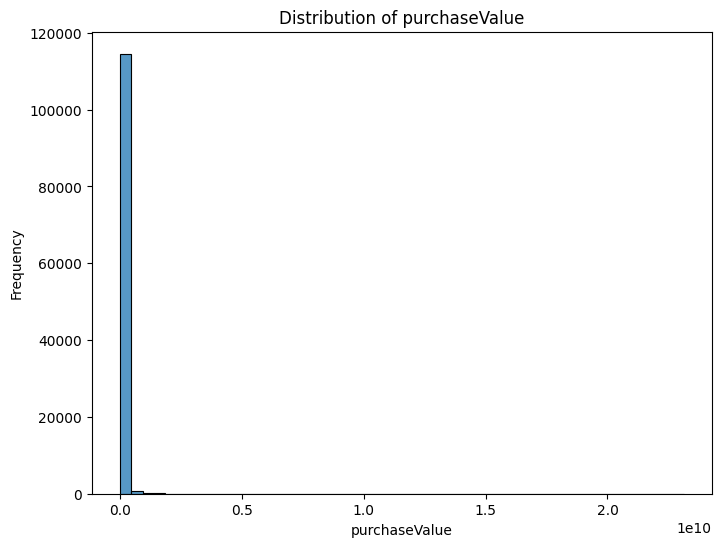

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.histplot(train['purchaseValue'],bins=50)
plt.title('Distribution of purchaseValue')
plt.xlabel('purchaseValue')
plt.ylabel('Frequency')
plt.show()

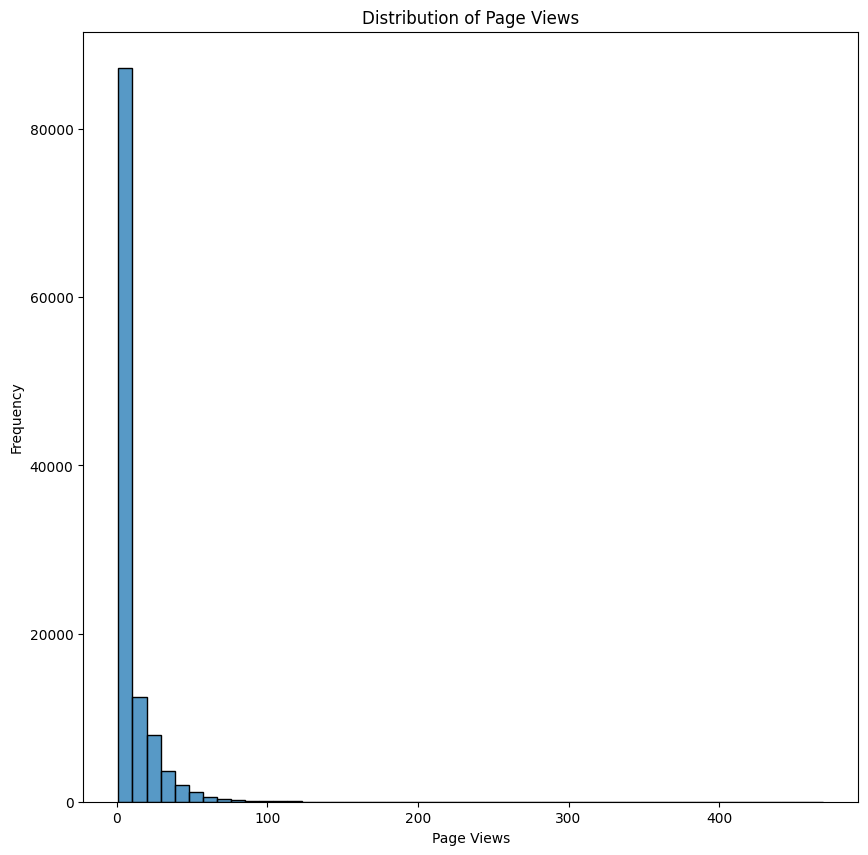

In [ ]:
plt.figure(figsize=(10,10))
sns.histplot(train['pageViews'],bins=50)


plt.title('Distribution of Page Views')
plt.xlabel('Page Views')
plt.ylabel('Frequency')
plt.show()

## Interpretation: purchaseValue


- Most observations are concentrated near **0**.
- A long tail extends towards very high purchase values.
- The distribution is **not symmetric**.



This confirms the observations from the summary statistics.

- Most customer sessions result in **no purchase**.
- Only a small proportion of customers make purchases.
- Among those who purchase, a few customers spend exceptionally large amounts.

Therefore, **purchaseValue is highly right-skewed**.


- Consider applying a **log transformation** to reduce skewness.
- Investigate extreme purchase values before deciding whether they are genuine customers or outliers.
- Tree-based models may naturally handle skewed data better than some linear models.

In [ ]:
train['browser'].value_counts()

,count
browser,
Chrome,84312
Safari,19160
Firefox,4026
Internet Explorer,2152
Android Webview,1471
Edge,1214
Safari (in-app),791
Opera Mini,732
Samsung Internet,563


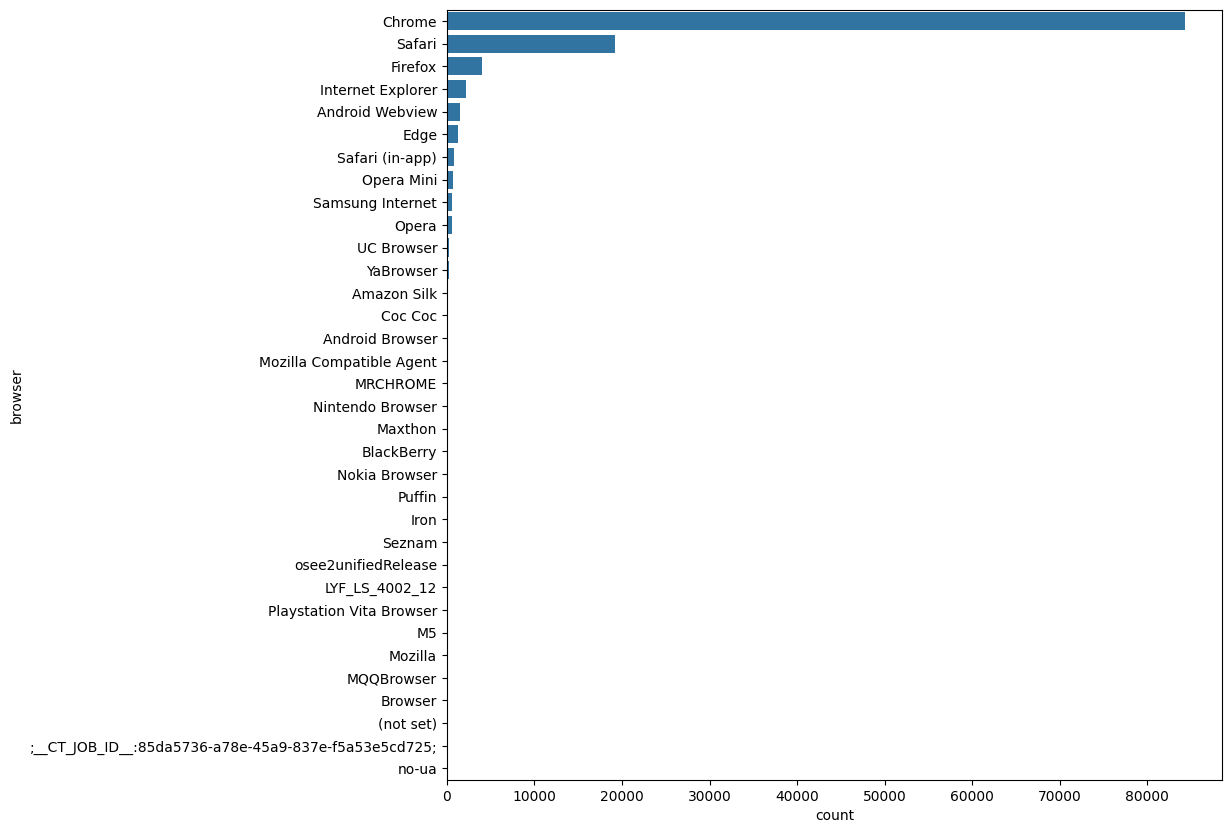

In [ ]:
plt.figure(figsize=(10,10))
sns.countplot(y=train['browser'],order=train['browser'].value_counts().index)
plt.show()

## Interpretation: pageViews

- Most sessions have very few page views.
- A small number of sessions have extremely high page views.
- The distribution is positively (right) skewed.


The majority of users browse only a few pages before leaving the website.

However, a few users browse many pages.

These sessions may represent:
- Highly engaged customers,
- Customers comparing products,
- Automated bots,
- Internal testing.


- Investigate the extreme values further using a **boxplot**.
- Check whether higher page views are associated with higher purchase values.
- Consider feature transformation if required.

# Step 8: Exploring Categorical Variables

Categorical variables describe different groups of observations.

Visualizing these variables helps us understand:
- Which categories dominate the dataset.
- Whether some categories are very rare.
- Whether feature encoding may be required.

## Questions

1. Which browser is used most frequently?
2. Are some browsers very rare?
3. Would grouping rare categories improve the model?

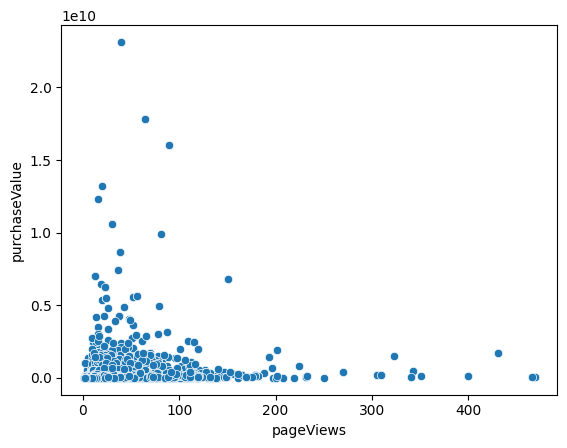

In [ ]:
sns.scatterplot(x='pageViews',y='purchaseValue',data=train)
plt.show()

# Step 9: Relationship Between Variables

EDA also studies relationships.

1. Does higher pageViews lead to higher purchaseValue?
2. Is there a strong linear relationship?
3. Would this feature be useful for prediction?

#log transformation of this data

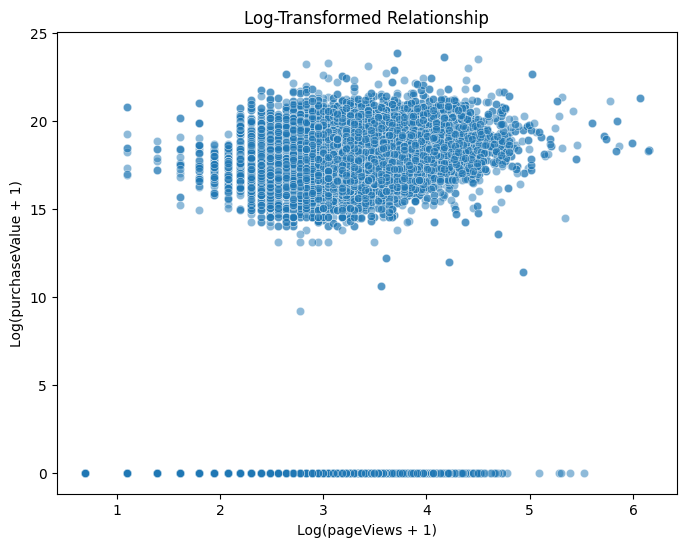

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply log transformation to both features
train['log_pageViews'] = np.log1p(train['pageViews'])
train['log_purchaseValue'] = np.log1p(train['purchaseValue'])

# 2. Plot the transformed data
plt.figure(figsize=(8, 6))
sns.scatterplot(x='log_pageViews', y='log_purchaseValue', data=train, alpha=0.5)

plt.title('Log-Transformed Relationship')
plt.xlabel('Log(pageViews + 1)')
plt.ylabel('Log(purchaseValue + 1)')
plt.show()

# Step 10: Correlation Analysis

Highly correlated variables may contain redundant information.


1. Which numerical variables are strongly correlated?
2. Should one of them be removed?

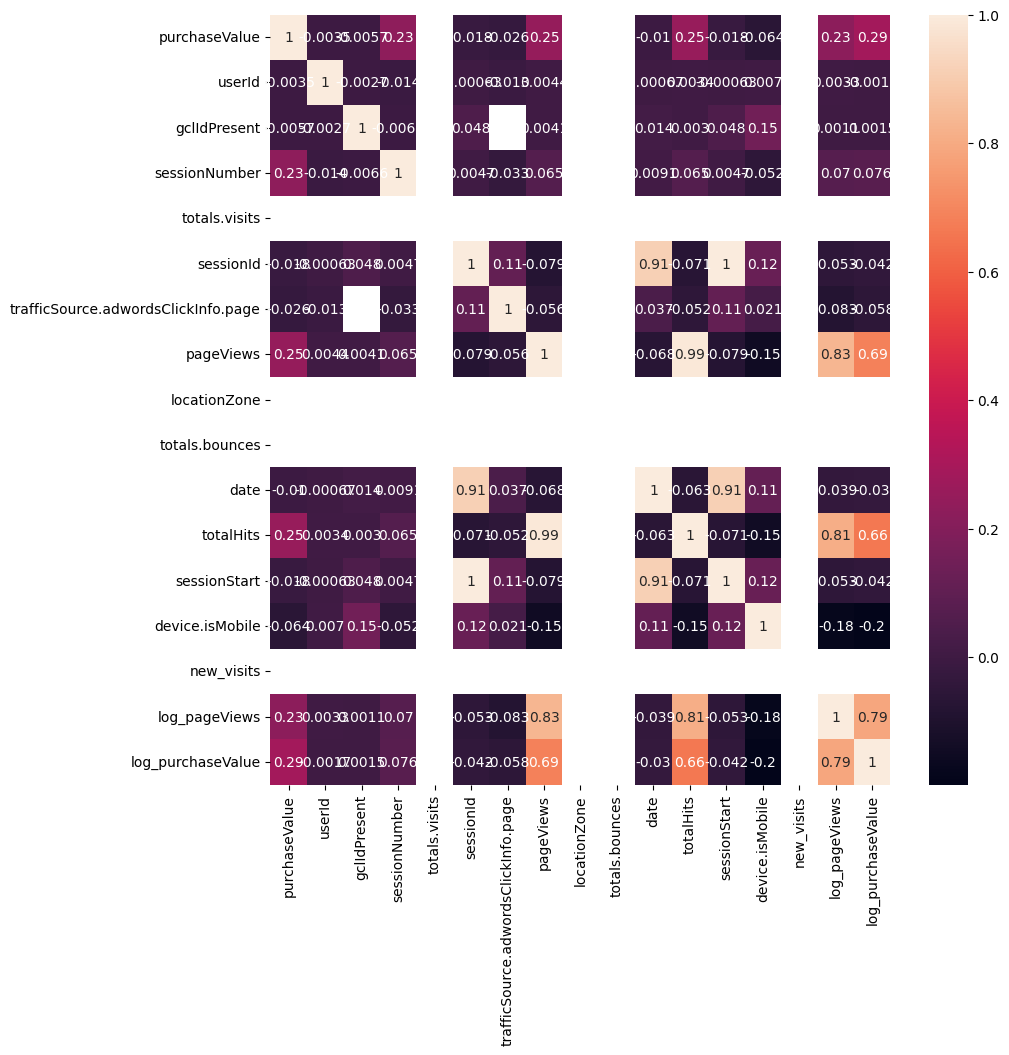

In [ ]:
corr =train.select_dtypes(exclude='object').corr()


plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)
plt.show()

# Step 11: Outlier Detection

Outliers may represent

- Data errors
- Fraud
- Premium customers
- Rare behaviour



1. Does purchaseValue contain outliers?
2. Should all outliers be removed?
3. How would you verify whether they are genuine?

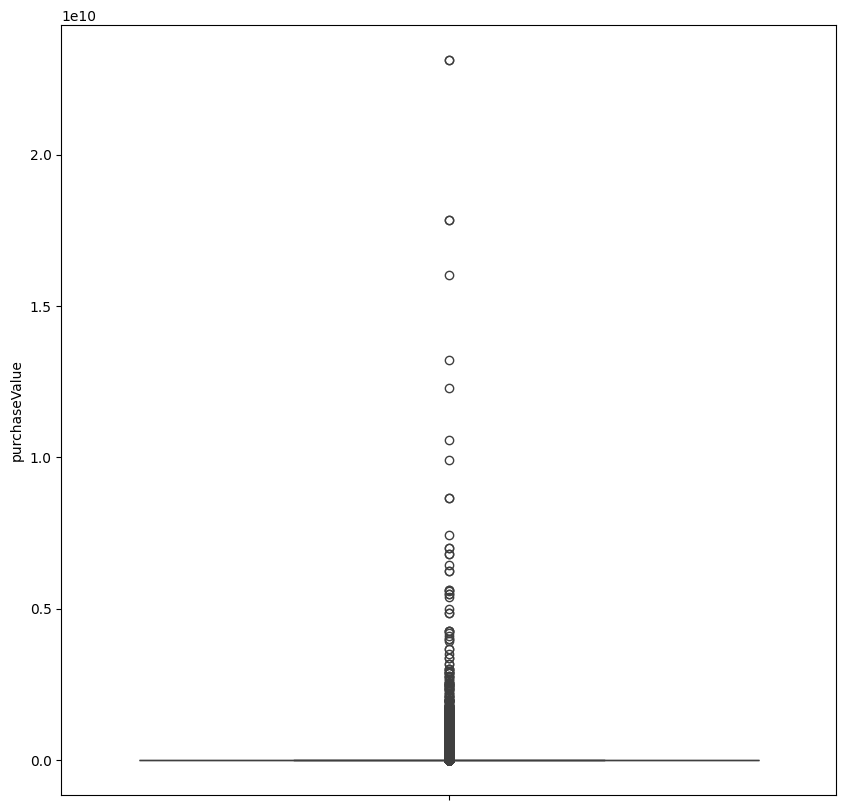

In [ ]:
plt.figure(figsize=(10,10))
sns.boxplot(train['purchaseValue'])
plt.show()

## Interpretation

### Observations

- Several observations lie far beyond the upper whisker.
- The majority of purchase values remain close to zero.


The boxplot confirms the presence of extreme purchase values.

These may represent:
- High-value customers,
- Fraudulent transactions,
- Data entry errors.

